In [ ]:
import numpy as np
import pandas as pd
import pickle
import deepchem as dc
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolDescriptors 
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit import DataStructs
import selfies as sf
from statistics import mean
from statistics import stdev
import tensorflow as tf
from tensorflow.python.eager import polymorphic_function
polymorphic_function.reduce_retracing = True
# Check versions of DeepChem and RDKit
dc_version = dc.__version__
rk_version = Chem.rdBase.rdkitVersion
print(f"DeepChem version: {dc_version}, RDKit version: {rk_version}")
# Suppress DeepChem warnings regarding missing dependencies
import warnings
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-geometric dependency")
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-lightning dependency")
warnings.filterwarnings("ignore", message="Skipped loading some Jax models")

DeepChem version: 2.8.0, RDKit version: 2022.09.5


In [3]:
ms = pd.read_pickle(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\_aromatic_2025_5955_CHN.pkl")
ms

,Name,Form,Mw,Cas,mz1,mz2,mz3,mz4,mz5,mz6,...,mz594,mz595,mz596,mz597,mz598,mz599,mz600,Filter_Form,SMILES,AtomGroup
318,2-Phenylethanamidine,C8H10N2,134,5504-24-5,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,NC(=N)Cc1ccccc1,CHN
395,"N,N-Bis[2,4-diamino-6-pteridylmethyl]adamantyl...",C24H29N13,499,98747-18-3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,Nc1nc(N)c2nc(CN(Cc3cnc4nc(N)nc(N)c4n3)C56CC7CC...,CHN
467,"s-Tetrazine, 3,6-bis(dipropylamino)-",C14H28N6,280,19455-90-4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCN(CCC)c1nnc(nn1)N(CCC)CCC,CHN
1346,"3,3-Dimethyl-1,4-diphenylazetidin-2-imine",C17H18N2,250,62834-02-0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC1(C)C(N(c2ccccc2)C1=N)c3ccccc3,CHN
2063,"Piperazine, 1-methyl-4-(1,2,3,4-tetrahydro-2-n...",C15H22N2,230,23853-58-9,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CN1CCN(CC1)C2CCc3ccccc3C2,CHN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181907,3-(t-Butyl)-5-azopyrazole,C7H14N4,154,139078-00-5,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC(C)(C)c1[nH]nc(NN)c1,CHN
181913,5-Ethyl-2-methyl-pyridin-4-amine,C8H12N2,136,5350-64-1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCc1cnc(C)cc1N,CHN
181926,"2-Naphthylamine, N-cyclohexyl-1,2,3,4-tetrahydro-",C16H23N,229,23853-48-7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,C1CCC(CC1)NC2CCc3ccccc3C2,CHN
182358,1-Methyl-2-aminomethylimidazole,C5H9N3,111,124312-73-8,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,Cn1ccnc1CN,CHN


In [ ]:
import deepchem as dc
import selfies as sf
import pandas as pd
X = ms.iloc[:, 4:604]     # spectra
y = ms.iloc[:, 605]       # smiles

se = []
dr = []  # list of indices to drop
c = 0

# Check all SMILES and filter out invalid/unsupported ones
for i in y:
    try:
        selfies_str = sf.encoder(i)
        se.append(selfies_str)
        if '.' in selfies_str:  # check for multi-molecule SMILES
            dr.append(c)
    except Exception as e:
        # Add to drop list if encoding fails (chemically invalid SMILES)
        dr.append(c)
    c += 1

# Drop problematic rows from original DataFrame
ms_cleaned = ms.drop(index=ms.index[dr]).reset_index(drop=True)

# Extract cleaned spectra and SMILES
X_clean = ms_cleaned.iloc[:, 4:604].to_numpy()
y_clean = ms_cleaned.iloc[:, 605].to_numpy()

# Create DeepChem dataset
ds = dc.data.DiskDataset.from_numpy(X_clean, y_clean)
ds

<DiskDataset X.shape: (np.int64(5955), np.int64(600)), y.shape: (np.int64(5955),), w.shape: (np.int64(5955),), task_names: [0]>

In [5]:
# Make a dictionary of all 'SELFIES' parts in the dataset

dataset = se
alphabet = sf.get_alphabet_from_selfies(dataset)
alphabet.add('[nop]')  # '[nop]' is a special padding symbol
alphabet = list(sorted(alphabet))
pad_to_len = max(sf.len_selfies(s) for s in dataset)
symbol_to_idx = {s: i for i, s in enumerate(alphabet)}
symbol_to_idx

{'[#Branch1]': 0,
 '[#Branch2]': 1,
 '[#C-1]': 2,
 '[#C]': 3,
 '[#N+1]': 4,
 '[#N]': 5,
 '[/-Ring1]': 6,
 '[/-Ring2]': 7,
 '[/C]': 8,
 '[/N]': 9,
 '[=Branch1]': 10,
 '[=Branch2]': 11,
 '[=C]': 12,
 '[=N+1]': 13,
 '[=N-1]': 14,
 '[=N]': 15,
 '[=Ring1]': 16,
 '[=Ring2]': 17,
 '[Branch1]': 18,
 '[Branch2]': 19,
 '[C-1]': 20,
 '[C@@H1]': 21,
 '[C@@]': 22,
 '[C@H1]': 23,
 '[C@]': 24,
 '[C]': 25,
 '[N+1]': 26,
 '[N-1]': 27,
 '[NH1]': 28,
 '[N]': 29,
 '[O]': 30,
 '[P]': 31,
 '[Ring1]': 32,
 '[Ring2]': 33,
 '[S]': 34,
 '[\\-Ring1]': 35,
 '[\\-Ring2]': 36,
 '[\\C]': 37,
 '[\\N]': 38,
 '[nop]': 39}

In [6]:
# Convert all SELFIES to ONE-HOT-FLAT (one-hot-flat can be used for machine learning)
sf_hot = sf.batch_selfies_to_flat_hot(se, vocab_stoi=symbol_to_idx, pad_to_len=pad_to_len)
# Create deepchem dataset X=spectrum y=SELFIES one-hot-flat
dataset = dc.data.NumpyDataset(X=np.array(ds.X, dtype='float'), y=sf_hot)

In [7]:
import deepchem as dc

seed = 123  
splitter = dc.splits.RandomStratifiedSplitter()

train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
    dataset=dataset,
    frac_train=0.9,
    frac_valid=0,
    frac_test=0.1,
    seed=seed
)

print(f"🔹 Seed used: {seed}")
print(f"📦 Training set size: {len(train_dataset)}")
print(f"📦 Validation set size: {len(valid_dataset)}")
print(f"📦 Test set size: {len(test_dataset)}")


🔹 Seed used: 123
📦 Training set size: 5308
📦 Validation set size: 0
📦 Test set size: 647


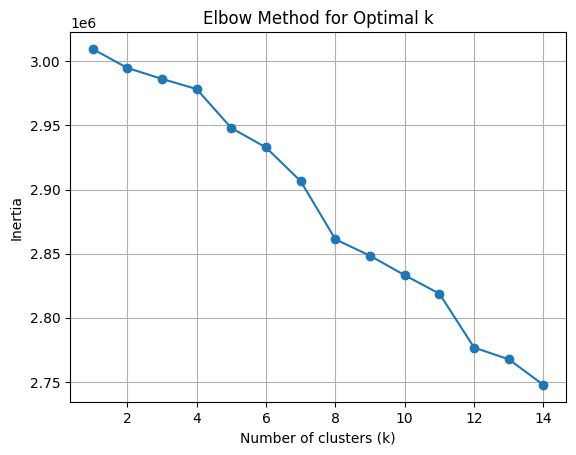

🔍 Elbow point detected at k = 1


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from kneed import KneeLocator 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_dataset.X)
inertias = []
k_range = range(1, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()
kl = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')
print(f"🔍 Elbow point detected at k = {kl.elbow}")

In [9]:
import os
import pickle
import numpy as np
from sklearn.cluster import KMeans

def train_and_save_kmeans_clusters(X_train, n_clusters=3,
                                   model_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with seed 123\kmeans_model",
                                   cluster_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  seed 123\clustering_from_trainset"):
    """
    Train KMeans on the training data, save the model, cluster data, and sample indices.

    Parameters:
    - X_train (np.ndarray): Training features
    - n_clusters (int): Number of clusters
    - model_dir (str): Path to save the KMeans model
    - cluster_dir (str): Path to save each cluster's data and indices

    Returns:
    - kmeans (KMeans): Trained model
    - cluster_files (dict): cluster_id -> file path for data and indices
    """
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(cluster_dir, exist_ok=True)

    # Train KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_train)

    # Save model
    model_path = os.path.join(model_dir, "kmeans_model.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(kmeans, f)
    print(f"✅ KMeans model saved to: {model_path}")

    # Save each cluster's data and indices
    cluster_files = {}
    for cluster_id in range(n_clusters):
        indices = np.where(labels == cluster_id)[0]
        cluster_data = X_train[indices]

        data_path = os.path.join(cluster_dir, f"cluster_{cluster_id}.pkl")
        idx_path = os.path.join(cluster_dir, f"cluster_{cluster_id}_indices.npy")

        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)
        np.save(idx_path, indices)

        cluster_files[cluster_id] = {
            "data_path": data_path,
            "indices_path": idx_path
        }

        print(f"📁 Cluster {cluster_id} saved: {data_path}")
        print(f"📌 Indices saved: {idx_path}")

    return kmeans, cluster_files
kmeans_model, cluster_paths = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=3)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  metho

In [10]:
import pickle

cluster_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  seed 123\clustering_from_trainset"
clusters = {}

for i in range(3):
    path = f"{cluster_dir}/cluster_{i}.pkl"
    with open(path, "rb") as f:
        clusters[i] = pickle.load(f)

for i in clusters:
    print(f"Cluster {i} shape: {clusters[i].shape}")



Cluster 0 shape: (957, 600)
Cluster 1 shape: (619, 600)
Cluster 2 shape: (3732, 600)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  metho

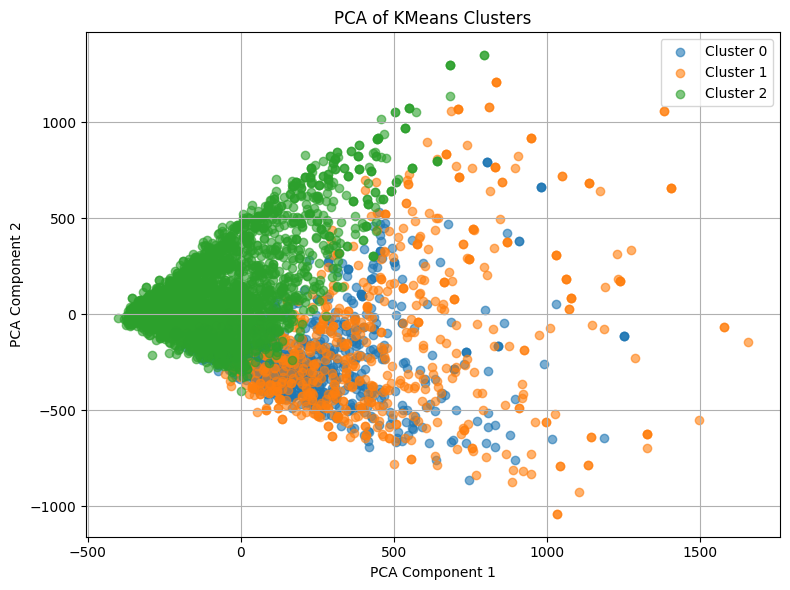

In [11]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_clusters_pca(X, labels, title="PCA of KMeans Clusters"):
    """
    Plots clustered instances using PCA to reduce to 2D.

    Parameters:
    - X (np.ndarray): The input data (e.g., from train_dataset.X)
    - labels (np.ndarray): Cluster labels assigned by KMeans
    - title (str): Title for the plot
    """
    # Perform PCA
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(X)

    # Plot clusters
    plt.figure(figsize=(8, 6))
    unique_labels = np.unique(labels)
    for cluster_id in unique_labels:
        idx = labels == cluster_id
        plt.scatter(reduced[idx, 0], reduced[idx, 1], label=f"Cluster {cluster_id}", alpha=0.6)

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
kmeans_model, _ = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=3)
labels = kmeans_model.predict(train_dataset.X)

# Plot clusters
plot_clusters_pca(train_dataset.X, labels)


In [ ]:
import pickle
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with seed 123\kmeans_model\kmeans_model.pkl", "rb") as f:
    kmeans_model = pickle.load(f)

In [ ]:


import os
import pickle
import numpy as np

def assign_and_save_clusters(X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test"):
    """
    Applies a trained KMeans model to a new dataset (e.g., test or validation),
    saves each cluster's data and sample indices.

    Parameters:
    - X (np.ndarray): Feature matrix (e.g., test_dataset.X)
    - kmeans_model (KMeans): Trained KMeans model
    - output_dir (str): Directory to save clustered data
    - dataset_label (str): Label for logging (e.g., "test" or "valid")
    """
    os.makedirs(output_dir, exist_ok=True)

    # Predict cluster labels
    cluster_labels = kmeans_model.predict(X)

    # For each cluster, save data and indices
    for cluster_id in np.unique(cluster_labels):
        indices = np.where(cluster_labels == cluster_id)[0]
        cluster_data = X[indices]

        # Save cluster data
        data_path = os.path.join(output_dir, f"cluster_{cluster_id}.pkl")
        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)

        # Save indices
        idx_path = os.path.join(output_dir, f"cluster_{cluster_id}_indices.npy")
        np.save(idx_path, indices)

        print(f"✅ Saved {dataset_label} cluster {cluster_id} to: {data_path}")
        print(f"📌 Indices saved to: {idx_path}")

    return cluster_labels
test_X = test_dataset.X 
test_clusters = assign_and_save_clusters(test_X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test")

✅ Saved test cluster 0 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy
✅ Saved test cluster 1 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1_indices.np

Cluster 0: size = 123, shape = (123, 600)
Cluster 1: size = 63, shape = (63, 600)
Cluster 2: size = 461, shape = (461, 600)


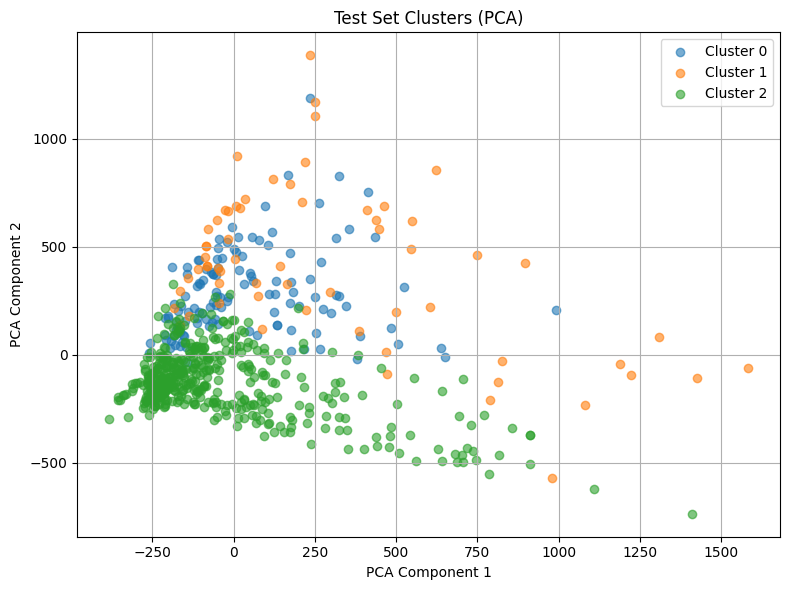

In [15]:

import pickle
import os

Test_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  Splitting  with seed 123\clustering_from_testset"
Test_clusters = {}

# Load clusters from pickle files
for i in range(3):  
    path = os.path.join(Test_dir, f"cluster_{i}.pkl")
    with open(path, "rb") as f:
        Test_clusters[i] = pickle.load(f)

# Print the size and shape of each cluster
for cluster_id, data in Test_clusters.items():
    print(f"Cluster {cluster_id}: size = {len(data)}, shape = {data.shape}")


plot_clusters_pca(test_X, test_clusters, title="Test Set Clusters (PCA)")


Epoch 1/100 - Loss: 0.261800
Epoch 2/100 - Loss: 0.031868
Epoch 3/100 - Loss: 0.028535
Epoch 4/100 - Loss: 0.026130
Epoch 5/100 - Loss: 0.024476
Epoch 6/100 - Loss: 0.023077
Epoch 7/100 - Loss: 0.021732
Epoch 8/100 - Loss: 0.020866
Epoch 9/100 - Loss: 0.019813
Epoch 10/100 - Loss: 0.018731
Epoch 11/100 - Loss: 0.017840
Epoch 12/100 - Loss: 0.016920
Epoch 13/100 - Loss: 0.015925
Epoch 14/100 - Loss: 0.014960
Epoch 15/100 - Loss: 0.014149
Epoch 16/100 - Loss: 0.013292
Epoch 17/100 - Loss: 0.012561
Epoch 18/100 - Loss: 0.011705
Epoch 19/100 - Loss: 0.011068
Epoch 20/100 - Loss: 0.010225
Epoch 21/100 - Loss: 0.009840
Epoch 22/100 - Loss: 0.009093
Epoch 23/100 - Loss: 0.008542
Epoch 24/100 - Loss: 0.008113
Epoch 25/100 - Loss: 0.007896
Epoch 26/100 - Loss: 0.007387
Epoch 27/100 - Loss: 0.006964
Epoch 28/100 - Loss: 0.006499
Epoch 29/100 - Loss: 0.006198
Epoch 30/100 - Loss: 0.005961
Epoch 31/100 - Loss: 0.005562
Epoch 32/100 - Loss: 0.005241
Epoch 33/100 - Loss: 0.004928
Epoch 34/100 - Loss

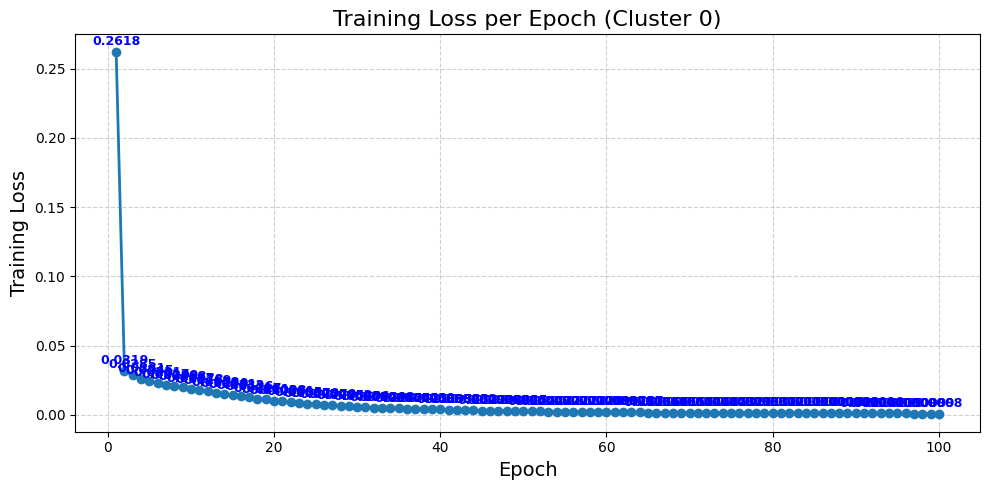

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  seed 123\models_\model0000


In [16]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 0 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl", "rb") as f:
    X_cluster0 = pickle.load(f)

cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy")
y_cluster0 = train_dataset.y[cluster_0_indices]

# Ensure y is 2D
if len(y_cluster0.shape) == 1:
    y_cluster0 = y_cluster0.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_0 = dc.data.NumpyDataset(X=np.array(X_cluster0), y=np.array(y_cluster0))

# === Model config
n_tasks = train_dataset_0.y.shape[1]
n_features = train_dataset_0.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_0 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  seed 123\models_\model0000"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_0.fit(train_dataset_0, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 0)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_0.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [17]:
import pickle
import numpy as np

# === Load cluster 0 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl", "rb") as f:
    X_test_cluster0 = pickle.load(f)

# === Load corresponding indices
test_cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster0 = test_dataset.y[test_cluster_0_indices]

if len(y_test_cluster0.shape) == 1:
    y_test_cluster0 = y_test_cluster0.reshape(-1, 1)


In [18]:

import deepchem as dc
test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

predictions_0 = model_0.predict(test_dataset_0)

print("✅ Prediction shape:", predictions_0.shape)
print("Example prediction:", predictions_0[0])



✅ Prediction shape: (123, 3000, 2)
Example prediction: [[1.0000000e+00 5.3520507e-13]
 [1.0000000e+00 2.7438718e-13]
 [1.0000000e+00 8.4640324e-12]
 ...
 [1.0000000e+00 8.4519822e-12]
 [1.0000000e+00 5.2343893e-12]
 [1.1661443e-13 1.0000000e+00]]


In [19]:
itos={}
c=0
for i in symbol_to_idx:
  itos[c]=i
  c=c+1
itos
from rdkit import Chem, DataStructs
import numpy as np


In [20]:

def evaluate_flat_predictions(predictions, test_dataset, itos, sf, cutoff=0.5):
    """
    Evaluate SELFIES predictions from flat one-hot output format.
    Args:
        predictions: model outputs (shape: [num_samples, sequence_len * vocab_size])
        test_dataset: DeepChem test dataset
        itos: index-to-symbol mapping (dict or list)
        sf: selfies module (with decoder)
        cutoff: threshold for class activation

    Returns:
        Prints evaluation stats and decoded examples
    """
    if isinstance(itos, list):
        itos = {i: tok for i, tok in enumerate(itos)}

    vocab_size = len(itos)
    total = len(test_dataset)
    hit = 0
    tanimoto_scores = []

    for idx in range(total):
        flat_pred = predictions[idx]
        binary_pred = [1 if val[1] >= cutoff else 0 for val in flat_pred]  

        num_tokens = len(binary_pred) // vocab_size
        selfie_str = ''
        for i in range(num_tokens):
            for j in range(vocab_size):
                if binary_pred[i * vocab_size + j] == 1 and itos[j] != '[nop]':
                    selfie_str += itos[j]

        try:
            pred_smiles = sf.decoder(selfie_str)
        except:
            pred_smiles = ''

        ground_truth_flat = test_dataset.y[idx]
        true_indices = np.argmax(ground_truth_flat.reshape(-1, vocab_size), axis=1)
        true_selfie = ''.join([itos.get(i, '') for i in true_indices])
        try:
            true_smiles = sf.decoder(true_selfie)
        except:
            true_smiles = ''

        # RDKit comparison
        mol_pred = Chem.MolFromSmiles(pred_smiles)
        mol_true = Chem.MolFromSmiles(true_smiles)
        if mol_pred is None or mol_true is None:
            tanimoto = 0.0
        else:
            fp_pred = Chem.RDKFingerprint(mol_pred)
            fp_true = Chem.RDKFingerprint(mol_true)
            tanimoto = DataStructs.FingerprintSimilarity(fp_pred, fp_true)

        tanimoto_scores.append(tanimoto)
        if pred_smiles == true_smiles:
            hit += 1

        print(f"[{idx}] Pred: {pred_smiles} | True: {true_smiles} | Tanimoto: {tanimoto:.3f}")

    # Summary
    tanimoto_scores = np.array(tanimoto_scores)
    print("\n📊 Evaluation Summary:")
    print(f"✅ Exact SMILES match: {hit}/{total} ({100*hit/total:.1f}%)")
    print(f"Tanimoto >= 1.0: {np.sum(tanimoto_scores == 1.0)}")
    print(f"Tanimoto >= 0.9: {np.sum(tanimoto_scores >= 0.9)}")
    print(f"Tanimoto >= 0.6: {np.sum(tanimoto_scores >= 0.6)}")
    print(f"Avg Tanimoto: {tanimoto_scores.mean():.3f}")


In [21]:
evaluate_flat_predictions(predictions_0, test_dataset_0, itos, sf, cutoff=0.5)


[0] Pred: C/C(=N/NC=NN)C1=CC=C(C=C1)N2C=NN=N2 | True: C/C(=N/NC=NN)C1=CC=C(C=C1)N2C=NN=N2 | Tanimoto: 1.000
[1] Pred: N1CCN(C1)CC2=CC=CC=C2 | True: N[C@H1]1CCN(C1)CC2=CC=CC=C2 | Tanimoto: 0.504
[2] Pred: CC(C)CN(CC(C)C)C1=NC=NC=2N(CC3=CC=CC=C3)N=NC1=2 | True: CC(C)CN(CC(C)C)C1=NC=NC=2N(CC3=CC=CC=C3)N=NC1=2 | Tanimoto: 1.000
[3] Pred: CC(CC)(N)NCCCC1=CC=CC=C1C2=C=CC=CC2C=C | True: CCC(C)N=CCC1=CC=CC=C1 | Tanimoto: 0.163
[4] Pred: CC=C(C1)N1CC | True: CN1N(CC2=CC=CC=C2)C1(C)C | Tanimoto: 0.051
[5] Pred: CC=C(C1)N1CC | True: CN1N(CC2=CC=CC=C2)C1(C)C | Tanimoto: 0.051
[6] Pred: CC=CC=CN(CNCC)C1C=CCC=C1 | True: C(CC1=CC=CC=C1)CC2=CC=NC=C2 | Tanimoto: 0.042
[7] Pred: C(N(CC1=CC=CC=C1)/N=C/C2=CC=CC=C2)C3=CC=CC=C3 | True: NC(C#N)C(CC1=CC=CC=C1)N(CC2=CC=CC=C2)CC3=CC=CC=C3 | Tanimoto: 0.214
[8] Pred: C1N(C)C=CC=C(C)CC#C1 | True: C(NC=1C=CC2=NN=C(N2N=1)C3=CC=CC=C3)C4=CC=CC=C4 | Tanimoto: 0.076
[9] Pred: CC1=CC2=CC=CC=C2C3N(N=C(N13)C4=CC=CC=C4)C5=CC=CC=C5 | True: CC1=CC2N(N=C(N2C3=CC=CC=C13)C4=CC=

Epoch 1/100 - Loss: 0.389656
Epoch 2/100 - Loss: 0.034867
Epoch 3/100 - Loss: 0.030260
Epoch 4/100 - Loss: 0.027687
Epoch 5/100 - Loss: 0.025931
Epoch 6/100 - Loss: 0.024402
Epoch 7/100 - Loss: 0.022979
Epoch 8/100 - Loss: 0.021572
Epoch 9/100 - Loss: 0.020417
Epoch 10/100 - Loss: 0.019034
Epoch 11/100 - Loss: 0.017796
Epoch 12/100 - Loss: 0.016565
Epoch 13/100 - Loss: 0.015280
Epoch 14/100 - Loss: 0.014092
Epoch 15/100 - Loss: 0.012041
Epoch 16/100 - Loss: 0.012111
Epoch 17/100 - Loss: 0.011003
Epoch 18/100 - Loss: 0.010065
Epoch 19/100 - Loss: 0.009356
Epoch 20/100 - Loss: 0.008526
Epoch 21/100 - Loss: 0.007763
Epoch 22/100 - Loss: 0.007295
Epoch 23/100 - Loss: 0.006802
Epoch 24/100 - Loss: 0.006293
Epoch 25/100 - Loss: 0.005655
Epoch 26/100 - Loss: 0.005292
Epoch 27/100 - Loss: 0.004777
Epoch 28/100 - Loss: 0.004488
Epoch 29/100 - Loss: 0.003428
Epoch 30/100 - Loss: 0.004019
Epoch 31/100 - Loss: 0.003676
Epoch 32/100 - Loss: 0.003432
Epoch 33/100 - Loss: 0.003121
Epoch 34/100 - Loss

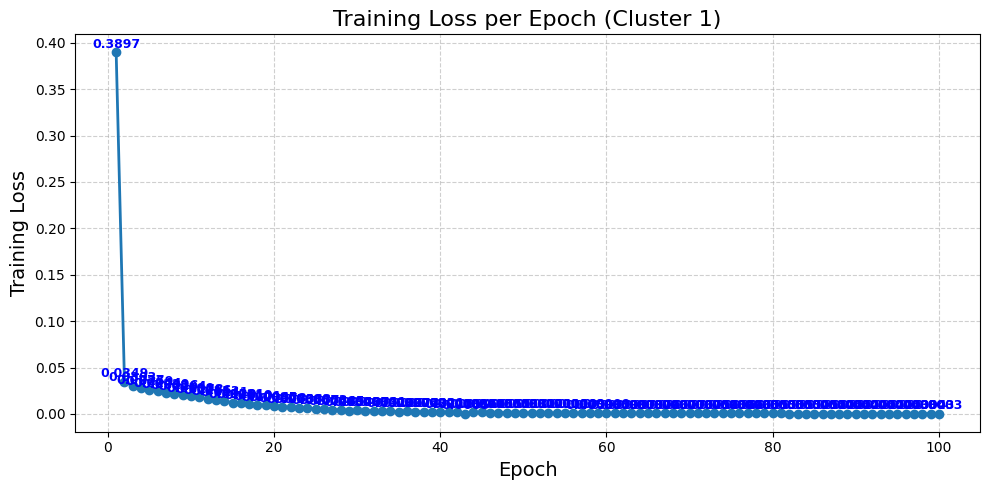

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with seed 123\models_\model1111


In [22]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 1 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl", "rb") as f:
    X_cluster1 = pickle.load(f)

cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  seed 123\clustering_from_trainset\cluster_1_indices.npy")
y_cluster1 = train_dataset.y[cluster_1_indices]

# Ensure y is 2D
if len(y_cluster1.shape) == 1:
    y_cluster1 = y_cluster1.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_1 = dc.data.NumpyDataset(X=np.array(X_cluster1), y=np.array(y_cluster1))

# === Model config
n_tasks = train_dataset_1.y.shape[1]
n_features = train_dataset_1.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_1 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with seed 123\models_\model1111"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_1.fit(train_dataset_1, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 1)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_1.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)



In [23]:
import pickle
import numpy as np
import deepchem as dc

# === Load cluster 1 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl", "rb") as f:
    X_test_cluster1 = pickle.load(f)

# === Load corresponding indices
test_cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster1 = test_dataset.y[test_cluster_1_indices]

if len(y_test_cluster1.shape) == 1:
    y_test_cluster1 = y_test_cluster1.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 1
test_dataset_1 = dc.data.NumpyDataset(X=np.array(X_test_cluster1), y=np.array(y_test_cluster1))

# === Predict using the trained model_1
predictions_1 = model_1.predict(test_dataset_1)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_1.shape)
print("Example prediction:", predictions_1[0])
evaluate_flat_predictions(predictions_1, test_dataset_1, itos, sf, cutoff=0.5)


✅ Prediction shape: (63, 3000, 2)
Example prediction: [[1.0000000e+00 2.9763470e-18]
 [1.0000000e+00 1.8642270e-19]
 [1.0000000e+00 2.0540652e-17]
 ...
 [1.0000000e+00 5.3007156e-17]
 [1.0000000e+00 1.4663031e-14]
 [1.4037057e-14 1.0000000e+00]]
[0] Pred: CC1CC(=NC=2C(C)=NN(C3=CC=CC=C3)C=2N1)C | True: CC1CC(=NC=2C(C)=NN(C3=CC=CC=C3)C=2N1)C | Tanimoto: 1.000
[1] Pred: CC1=NN2N=C(C)C(C)=NC2=N1 | True: CC1=NN2N=C(C)C(C)=NC2=N1 | Tanimoto: 1.000
[2] Pred: CC1CN(C)C(C)CC1NC2=CC=CC=C2 | True: CC1CN(C)C(C)CC1NC2=CC=CC=C2 | Tanimoto: 1.000
[3] Pred: C=1CC=C(C)C=1CC(=C)C=CC=CCC | True: C1CCC(CC1)NC=2N(N=NC=2C=3C=C[NH1]N=3)C4CCCCC4 | Tanimoto: 0.079
[4] Pred: CC=1C=CC2=NN=NN2C=1 | True: CC=1C=CN2N=NN=C2C=1 | Tanimoto: 0.666
[5] Pred: CC(N)C(C)C=CC=C | True: CN(C)C=NC1=CC=CC=C1 | Tanimoto: 0.016
[6] Pred: C1CCN(C)C\C=N/NC=C(/C)C=N1 | True: C1CN2CCC1C(/C2)=C/C3=CC=CC=C3 | Tanimoto: 0.128
[7] Pred: CC(C)CCCC1=CC=CC=C1C | True: CNC1=NC(N)=NC(N)=C1C2=CC=CC=C2 | Tanimoto: 0.076
[8] Pred: CC1=CC(=NC(=N

Epoch 1/100 - Loss: 0.091774
Epoch 2/100 - Loss: 0.028528
Epoch 3/100 - Loss: 0.025022
Epoch 4/100 - Loss: 0.024421
Epoch 5/100 - Loss: 0.023262
Epoch 6/100 - Loss: 0.022113
Epoch 7/100 - Loss: 0.021264
Epoch 8/100 - Loss: 0.017462
Epoch 9/100 - Loss: 0.019496
Epoch 10/100 - Loss: 0.018741
Epoch 11/100 - Loss: 0.017892
Epoch 12/100 - Loss: 0.017152
Epoch 13/100 - Loss: 0.016460
Epoch 14/100 - Loss: 0.015826
Epoch 15/100 - Loss: 0.015061
Epoch 16/100 - Loss: 0.013665
Epoch 17/100 - Loss: 0.013682
Epoch 18/100 - Loss: 0.013040
Epoch 19/100 - Loss: 0.012643
Epoch 20/100 - Loss: 0.011926
Epoch 21/100 - Loss: 0.011337
Epoch 22/100 - Loss: 0.010819
Epoch 23/100 - Loss: 0.010418
Epoch 24/100 - Loss: 0.010009
Epoch 25/100 - Loss: 0.009623
Epoch 26/100 - Loss: 0.009203
Epoch 27/100 - Loss: 0.008974
Epoch 28/100 - Loss: 0.008503
Epoch 29/100 - Loss: 0.006258
Epoch 30/100 - Loss: 0.007790
Epoch 31/100 - Loss: 0.007413
Epoch 32/100 - Loss: 0.007444
Epoch 33/100 - Loss: 0.007059
Epoch 34/100 - Loss

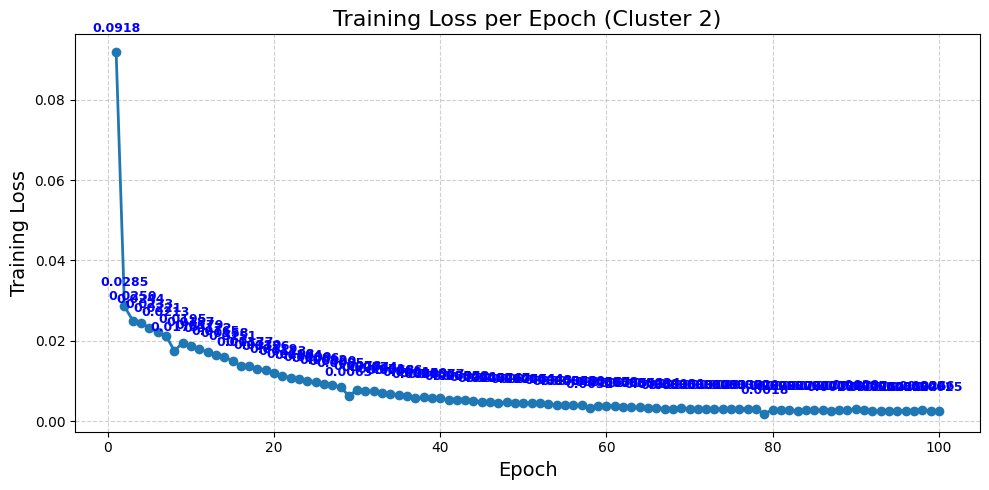

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with seed 123\models_\model2222


In [24]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 2 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  seed 123\clustering_from_trainset\cluster_2.pkl", "rb") as f:
    X_cluster2 = pickle.load(f)

cluster_2_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  seed 123\clustering_from_trainset\cluster_2_indices.npy")
y_cluster2 = train_dataset.y[cluster_2_indices]

if len(y_cluster2.shape) == 1:
    y_cluster2 = y_cluster2.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_2 = dc.data.NumpyDataset(X=np.array(X_cluster2), y=np.array(y_cluster2))

# === Model config
n_tasks = train_dataset_2.y.shape[1]
n_features = train_dataset_2.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_2 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with seed 123\models_\model2222"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_2.fit(train_dataset_2, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 2)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_2.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [25]:
# === Load cluster 2 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_2.pkl", "rb") as f:
    X_test_cluster2 = pickle.load(f)

# === Load corresponding indices
test_cluster_2_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_5955_CHN\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_2_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster2 = test_dataset.y[test_cluster_2_indices]

if len(y_test_cluster2.shape) == 1:
    y_test_cluster2 = y_test_cluster2.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 2
test_dataset_2 = dc.data.NumpyDataset(X=np.array(X_test_cluster2), y=np.array(y_test_cluster2))

# === Predict using the trained model_2
predictions_2 = model_2.predict(test_dataset_2)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_2.shape)
print("Example prediction:", predictions_2[0])

evaluate_flat_predictions(predictions_2, test_dataset_2, itos, sf, cutoff=0.5)


✅ Prediction shape: (461, 3000, 2)
Example prediction: [[1.0000000e+00 5.2936554e-20]
 [1.0000000e+00 1.3045952e-21]
 [1.0000000e+00 1.3168531e-24]
 ...
 [1.0000000e+00 2.3022553e-22]
 [1.0000000e+00 2.2893004e-24]
 [1.2424699e-24 1.0000000e+00]]
[0] Pred: CCCN(CCC)C1=NN=C(N=N1)N(CCC)CCC | True: CCCN(CCC)C1=NN=C(N=N1)N(CCC)CCC | Tanimoto: 1.000
[1] Pred: NNC=1[NH1]N=NN=1 | True: NNC=1[NH1]N=NN=1 | Tanimoto: 1.000
[2] Pred: C1CN2CN3CN1CC(C2)(C3)N=CC4=CC=CC=C4 | True: C1CN2CN3CN1CC(C2)(C3)N=CC4=CC=CC=C4 | Tanimoto: 1.000
[3] Pred: CC=1C=C(C)N(N=1)C2=NN=C(N=N2)N3CCCC3 | True: CC=1C=C(C)N(N=1)C2=NN=C(N=N2)N3CCCC3 | Tanimoto: 1.000
[4] Pred: CC1=N[NH1]N=C1N2CCN(CC2)C3=N[NH1]N=C3C | True: CC1=N[NH1]N=C1N2CCN(CC2)C3=N[NH1]N=C3C | Tanimoto: 1.000
[5] Pred: NC1=NN2C(N)=N[NH1]C2=N1 | True: NC1=NN2C(N)=N[NH1]C2=N1 | Tanimoto: 1.000
[6] Pred: C=CCNC1=NN=C(NCC=C)N=N1 | True: C=CCNC1=NN=C(NCC=C)N=N1 | Tanimoto: 1.000
[7] Pred: N#CC1=CC=C(C#N)C(=C1)C2CCCCC2 | True: N#CC1=CC=C(C#N)C(=C1)C2CCCCC2 | Tan